# AI Agents for Scientific Simulation and Data Analysis

Computational scientists come from diverse domains and backgrounds, but they tend to use HPC in similar ways: one runs a simulation and processes data, iterating until a new observation emerges. The bulk of scientific reasoning happens in the interpretation of these simulations, but as scientific computation becomes more sophisticated and resource-heavy, researchers can spend undue time on tasks like debugging, environment setup, and determining input file formats. The situation is particularly daunting for new users: it may take weeks or months for a new graduate student to gain confidence using complex simulators like OpenFOAM or GIZMO. Is there a way to automate some of these setup tasks, and allow scientists to focus on refining their hypotheses?

The answer is yes, and the trick is to program an agent to **orchestrate** the code base. This leaves the agent to handle the cumbersome or unintuitive aspects of numerical work, while the researcher is free to interpret results, come up with new hypotheses, and plan further simulations. In this tutorial we will build an agent that can execute Python code, giving it access to several pre-written scripts relevant to scientific computing. Specifically, we will:

- **Part 1**: Build an agent to select and run Python code
- **Part 2**: Use the agent to run a scientific simulation
- **Part 3**: Use the agent to process a scientific dataset

We build our agent using as simple a framework as possible, such that its various components can be taken apart and understood.

Note that we'll need to take care of a few book-keeping items first, i.e., starting an Ollama server in the background of our Jupyter notebook. This gives us an easy-to-use interface for querying the LLM "brain" that drives an agentic workflow. While there are many methods for initializing an LLM backend, Ollama is our preferred approach because of its straightforward integration of TACC GPU resources:

In [2]:
# Launch Ollama server in background
import subprocess, os, signal, time, atexit, pathlib

# Create log file
log_file = "ollama_server.log"

# Kill any existing ollama processes
subprocess.run(["pkill", "ollama"], capture_output=True)
time.sleep(2)

# Start ollama serve in background
print("Starting Ollama server...")
process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=open(log_file, "w"),
    stderr=subprocess.STDOUT,
    preexec_fn=os.setpgrp
)
print(f"Server logs: {log_file}")
print(f"API endpoint: http://localhost:11434")

# Wait for server to start
print("Waiting 5 seconds for server startup...")
time.sleep(5)

# Store process PID globally for cleanup
if 'OLLAMA_PROCESS' not in globals():
    OLLAMA_PROCESS = process.pid
    print(f"Ollama server ready! PID: {OLLAMA_PROCESS}")
else:
    print("Ollama server already running!")

# Register cleanup function
def cleanup_ollama():
    try:
        if 'OLLAMA_PROCESS' in globals():
            os.killpg(os.getpgid(OLLAMA_PROCESS), signal.SIGTERM)
            print("Ollama server stopped")
    except:
        pass

atexit.register(cleanup_ollama)

Starting Ollama server...
Server logs: ollama_server.log
API endpoint: http://localhost:11434
Waiting 5 seconds for server startup...
Ollama server ready! PID: 75494


<function __main__.cleanup_ollama()>

In [3]:
# Copy data file for data analysis demonstration
if not pathlib.Path('./data/VORTALL.mat').is_file():
    !cp /scratch/projects/tacc/sci-training/PEARC2026/data/VORTALL.mat ./data/.

# Optional: Refresh demo output folders before proceeding
! rm -r images
! mkdir images
! mkdir images/pendulum
! mkdir images/vortex_method
! mkdir images/pca

## Part 1: Build an agent to run Python code

The cornerstone of our agent framework is structured generation, and the basic building blocks of our agent will look very familiar those discussed in our first notebook. That is, we will connect to an LLM backend, setup schema and tool calls for running python code, and adjust our agent's reasoning loop with new capabilities. Let's explore each of these broad steps in detail before seeing the completed agent in action.


### Connect to an LLM Backend

Just like our introductory tutorial, the first step of this demo is to establish an LLM backend. As we'll see later in the tutorial, the choice of backend is one of the most significant determining factors in an agent's performance. For this tutorial, we'll connect to a modestly sized model (gemma3:27b) running on a local Ollama server, but keep in mind that this choice can be substituted for any model/provider with an OpenAI-compatible endpoint. 

In [3]:
from outlines import from_openai, Template
from pydantic import BaseModel, Field
from openai import OpenAI
from typing import Optional, List, Dict, Literal, Union
import json
import subprocess
import os, uuid
import tempfile
import shlex

# Connect to an LLM Backend
openai_client = OpenAI(
            api_key="ollama", 
            base_url="http://localhost:11434/v1"
            )
backend_model = from_openai(openai_client, model_name='gemma3:27b') # qwen3-coder-next

### Set up schema for code evaluation

Here, we use Pydantic to define schema for our code execution task. Each schema represents an individual tool call; for this example, each of these tools corresponds to a pre-validated python script. At each step in its reasoning loop, the agent will choose which of these tools is best suited to complete the task. It will then populate the tool's input parameters based on the schema specified below. 

As a starting point, we specify two tools for the agent: (1) a calculator, which simply adds two numbers together, and (2) a vortex method, which is our stand-in for a physics simulator. We also specify a schema for a final summary, which should be chosen when the task is complete. Note that each schema includes an input_string method that formats how inputs should be arranged on the command line. 

In [4]:
class CalculatorInputs(BaseModel):  
    type: Literal["CalculatorInputs"]
    script_name: Literal["calculator.py"]
    num1: float = Field(..., description="The first number to be added")
    num2: float = Field(..., description="The second number to be added")
    def input_string(self) -> str:
        return f"--num1 {self.num1} --num2 {self.num2}"

class VortexInputs(BaseModel):
    type: Literal["VortexInputs"]
    script_name: Literal["vortex_method.py"]
    xpos: List[float] = Field(..., description="Initial x location of vortex particles in the x-y plane")
    ypos: List[float] = Field(..., description="Initial y location of vortex particles in the x-y plane")
    gamma: List[float] = Field(..., description="Strength of each vortex")
    tsim: float = Field(..., description="Total time over which simulation is advanced")
    num_snapshots: int = Field(..., description="Number of snapshots to save throughout simulation")
    def input_string(self) -> str:
        xpos_str = " ".join(map(str, self.xpos))
        ypos_str = " ".join(map(str, self.ypos))
        gamma_str = " ".join(map(str, self.gamma))
        return f"--xpos {xpos_str} --ypos {ypos_str} --gamma {gamma_str} --tsim {self.tsim} --num_snapshots {self.num_snapshots}" 

class FinalSummary(BaseModel):
    type: Literal["FinalSummary"]
    summary: str = Field(..., description="Final summary of the problem when the task is complete and you are ready to exit.")          

### Set up schema for selecting an action

Thus far we have defined our agent's tools, but we have yet to specify how it will choose the appropriate action among them. For this task, we define a new schema called AgentAction, which makes use of Pydantic's Union function. This function constrains the LLM such that it populates only one of several schema from a list. It makes this choice by first populating the "discriminator" field ( which is common to all tools) based on the user's prompt. Pydantic then validates the LLM's response against the specific schema that matches the discriminator.

In [5]:
# Set up schema for reasoning module
class AgentAction(BaseModel):
    thought: str = Field(..., description="Internal reasoning about what to do next.")
    action: Union[VortexInputs, CalculatorInputs, FinalSummary] = Field(...,discriminator="type")

### Set up the agent's reasoning loop

Having set up the schema for our tools calls, the final component of our agent is its reasoning loop, which determines what information will be fed into the prompt for each tool call, and what the agent should do with each tool once called. For this example, we set up a simple ReAct-style reasoning loop, in which the agent plans one step at a time. At the first iteration, the agent uses a simple prompt template (select_code_template.txt) and selects a tool. If the tool is a python script, we instruct the agent to execute it; if the tool is a final summary, we instruct the agent to exit the loop. After each iteration, the outcome of the previous attempt (along with the agent's internal reasoning) is appended to the prompt, and the process repeats.


In [6]:
# Main agent reasoning loop
def select_code_agent(user_input: str, max_steps, model):

    # Initialize the prompt with code generation instructions (the full prompt can be found in generate_code_template.txt)
    select_code_template = Template.from_file('select_code_template.txt')
    context = select_code_template(
                user_task=user_input)
    messages: List[Dict] = [{"role": "user", "content": context}]
    observations = []

    # Loop through steps
    for step in range(max_steps):
        print(f"\n--- Step {step + 1} ---")
        prompt = "\n".join([f"{m['role']}: {m['content']}" for m in messages])
        if observations:
            prompt += f"\nLatest Observation: {observations[-1]}"

        # Generate structured response
        try:
            response = model(prompt, AgentAction)
            action_obj = (
                response if isinstance(response, AgentAction)
                else AgentAction.model_validate_json(response)
            )
        except Exception as e:
            print(f"Parse error: {e}")
            return {"error": "Generation failed"}

        # Handle tool calls
        if not isinstance(action_obj.action, FinalSummary):
            tool = action_obj.action
            print(f"Thought: {action_obj.thought}")
            script_name = action_obj.action.script_name
            input_string = action_obj.action.input_string()
            result = subprocess.run(["python", "./tools/"+script_name, *shlex.split(input_string)], text=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
            output = result.stdout + result.stderr
                        
            print(f"Tool Call: {tool.__class__.__name__}")

            if result.returncode==0:
                print(f"Code generation returned 'success' with the following output: \n{output}")
                observation = (
                f"Code execution suceeded.\n"
                f"Here is the code that was run:\n\n" 
                f"{action_obj.action.script_name}\n\n" 
                f"Execution result:\n{output}\n\n"
                )
                
            else:
                print(f"Code generation failed with the following output: \n{output}")
                observation = (
                f"Code generation failed.\n"
                f"Here is the code that was run:\n\n" 
                f"{action_obj.action.script_name}\n\n" 
                f"Execution result:\n{output}\n\n"
                )
                
            observations.append(observation)  
            messages.extend([
                {"role": "assistant", "content": f"Action: {tool.__class__.__name__}"},
                {"role": "system", "content": observation}
            ])
        
        elif isinstance(action_obj.action, FinalSummary):
            print(f"The task is complete. Here is a final summary of my work: \n{action_obj.action.summary}")
            return action_obj.action.summary

        else:
            print("No action or final summary returned.")
            break

    return {"error": f"Max steps ({max_steps}) reached without generated code"}   

### Run a test case

We now have a functioning agent! Let's verify our work by prompting the agent to solve a very simple arithmetic problem. We should see the agent should select the calculator tool, execute the code, and return a final summary.

In [7]:
# Simple test case
user_input = "Use a Python code to answer: 1+1=?"
result = select_code_agent(user_input = user_input, max_steps = 3, model=backend_model)


--- Step 1 ---
Thought: The user is asking a simple arithmetic question. The `CalculatorInputs` tool is perfectly suited for this task. No other tools are needed.
Tool Call: CalculatorInputs
Code generation returned 'success' with the following output: 
1.0 + 1.0 = 2.0


--- Step 2 ---
The task is complete. Here is a final summary of my work: 
The calculation 1+1 equals 2.0. The task is completed.


## Part 2:  Use the agent to write and run a scientific simulation

The framework above is simple but powerful. By giving the agent authority to execute Python, many scientific computing tasks reduce to communicating input requirements through the prompt. This is one reason why 'prompt engineering' has become such a popular topic in recent years. The user can ask the agent simple request like 'use python to run a fluid dynamics simulation" and the agent in theory has the tools to execute such a script without further intervention.

For some scientific disciplines, this degree of autonomy presents an issue. Particularly in the case of compute-heavy simulations (e.g., fluid dynamics, computational chemistry, structural mechanics), one risks draining computational resources if the setup parameters are chosen carelessly. What's more, legacy simulation codes often lack complete documentation, making it even harder to setup guardrails for the agent. This is the domain of bespoke coding agents, in which an agent's prompt, tools, and reasoning modules are heavily refined for tasks native to a specific sub-domain. 

In this part of the tutorial, we will stick to very simple, canonical simulations that can be solved with a single python script. Specifically, we draw an example from fluid dynamics, and ask the agent to simulate the interaction of two point vortices in a potential flow. In the example below, we should see the agent (1) identify the correct script for vortex simulation and (2) populate its input schema with values extracted from the prompt.


In [8]:
# Incorporate domain-specific knowledge via the prompt
user_input = "Run a point vortex simulation with two vortices. \
The vortcies must both have a circulation of +1. \
The vortices must be located 1m apart from one another. \
Advance the simulation for 5s. \
Save 20 flowfields regularly spaced in time from the simulation."

result = select_code_agent(user_input = user_input, max_steps = 3, model=backend_model)



--- Step 1 ---
Thought: The user wants to perform a point vortex simulation with specified parameters and save flowfields at regular intervals. The `VortexInputs` tool is designed for this purpose. I will use it to set up and run the simulation, specifying the number of vortices, their circulation, initial positions, simulation duration, and the number of flowfields to save. No other tools are needed for this task. After the simulation is run and the flowfields are saved, I will use `FinalSummary` to indicate the task is complete.
Tool Call: VortexInputs
Code generation returned 'success' with the following output: 
All figures generated and saved


--- Step 2 ---
The task is complete. Here is a final summary of my work: 
The point vortex simulation has been successfully run with two vortices of circulation +1, initially 1m apart, for 5 seconds. 20 flowfields were saved at regular time intervals. The simulation code `vortex_method.py` was executed successfully.


We can look in the output directory and see exactly what the agent has returned as its simulation.

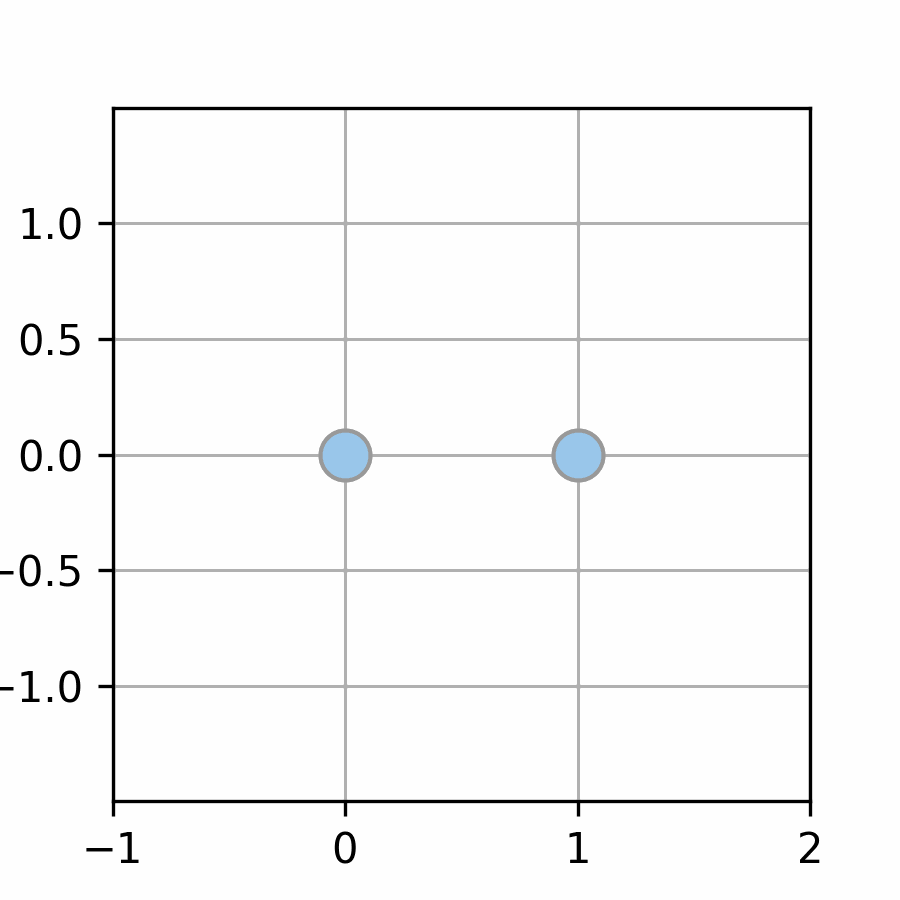

In [9]:
from PIL import Image
import glob
from IPython.display import Image as IPImage, display

# Get PNG files (adjust path / sort as needed)
png_files = sorted(glob.glob("./images/vortex_method/*.png"))

frames = [Image.open(p) for p in png_files]

# Save as GIF
frames[0].save(
    "animation.gif",
    save_all=True,
    append_images=frames[1:],
    duration=200,  # milliseconds per frame
    loop=0         # 0 = infinite loop
)

# Display gif within Jupyter
display(IPImage(filename="animation.gif")) 

Based on the image sequence above, the agent was indeed able to select the correct code and complete a potential flow simulation. There are several important observations regarding this outcome: 

- Depending on your back-end model, the agent may have needed several attempts before successfully completing the simulation. This is very normal. In fact it demonstrates a key feature of AI agents: they incorporate observations from previous actions into their plan for next steps. This is one of the core traits that differentiates an AI agent from a traditional LLM.
  
- The prompt was quite extensive, even for this simple simulation! One can imagine that if we had asked the agent to run a finite volume solver, the number of required input parameters would increase quite a bit, and restrictions in the prompt would need to become more extensive. This is one of the main questions driving research into agentic systems: can we build robust agents without populating their prompts with increasingly complex instructions? Alternatively, if the prompt is missing a key input parameter, how can we ensure that the agent selects a reasonable value for our application? Beyond prompt-engineering, techniques for guiding the agent's behavior include dynamic planning, nested schema, and RAG-inspired ingestion; however, solutions to the prompt engineering problem remain an ongoing area of research. 

### The effect of LLM backend

In the simulation above, we saw that the user's primary means of controlling the agent is through the agent's prompt. Indeed, when designing an agent to perform a specific task, much of the work lies in configuring the agent's prompt and reasoning module such that the agent's failure rate is minimized. We stress, however, that improvements from prompt-engineering often have an upper threshold, and this upper threshold is largely defined by the capacity of the chosen LLM backend.

To demonstrate this, let's try to re-run our simulation using a LESS powerful LLM as our backend model. The following code block runs our coder-agent with gemma3:1b, which has just a fraction of the parameters alloted to gemma3:27b. Let's see how our under-powered model performs:

In [11]:
# Define a new LLM backend
backend_model_new = from_openai(openai_client, model_name='gemma3:1b')

# Incorporate domain-specific information via the prompt
user_input = "Run a point vortex simulation with two vortices. \
The vortcies must both have a circulation of +1. \
The vortices must be located 1m apart from one another. \
Advance the simulation for 5s. \
Save 20 flowfields regularly spaced in time from the simulation."

# Run the agent with our new backend
result = select_code_agent(user_input = user_input, max_steps = 3, model=backend_model_new)


--- Step 1 ---
Thought: Okay, I need to generate Python code for a point vortex simulation with two vortices, each with a circulation of +1, separated by 1 meter. I'll use the VortexInputs tool for this.  I'll save 20 flowfields at regular intervals over 5 seconds.
Tool Call: VortexInputs
Code generation failed with the following output: 
usage: vortex_method.py [-h] [--xpos XPOS [XPOS ...]] [--ypos YPOS [YPOS ...]]
                        [--gamma GAMMA [GAMMA ...]] [--tsim TSIM]
                        [--num_snapshots NUM_SNAPSHOTS]
                        [--write_dir WRITE_DIR]
vortex_method.py: error: argument --xpos: expected at least one argument


--- Step 2 ---
Thought: I need to generate a Python code that runs a point vortex simulation with two vortices, both with a circulation of +1, located 1m apart from one another. It also needs to save 20 flowfields regularly spaced in time from the simulation.
Tool Call: VortexInputs
Code generation failed with the following output: 

For most runs of this under-powered backend, the agent will correctly select the vortex simulation code, but it will fail to correctly populate the code's input schema. In some instances, the agent may not even make it past the first step, which is to acknowledge that it must run a code. It simply tells the user that it wrote a code and saved data, without actually doing anything! The takeaweay from this example is thus: the choice of LLM backend often has the most significant impact on the agent's ability to consistently choose the correct tool. 

A warning: while the LLM backend generally sets the agent's upper capacity, one should not neglect prompt-engineering and clever reasoning loops. Well-designed agents are capable of operating with smaller models, ultimately saving compute time and API cost.

## Part 3: Use the agent to process a scientific dataset

The previous section gave some insight into running simulations with an AI agent, identifying areas where that process is easy (launching a general simulation) and difficult (incorporating domain-specific guardrails into the prompt). Many of these strengths and weaknesses also apply to the next step in a scientific workflow: data analysis. With its coding capabilities, an AI agent is capable of accessing and computing statistics using the data output from a scientific simulation, making it a natural fit for rapid data processing.

In this part of the tutorial, we will use our coding-agent to interact with VORTALL.mat, a custom file output from a high-resolution fluid dynamics simulation. Specifically, we will outfit the agent with a tool call for principal component analysis (PCA), in which the agent opens a local file and assesses its complexity.


In [12]:
class PCAInputs(BaseModel):
    type: Literal["PCAInputs"]
    script_name: Literal["pca.py"]
    file_to_query: str = Field(..., description="The path of the data file.")
    num_modes: int = Field(..., description="The number of modes to retain in PCA.")
    def input_string(self) -> str:
        return f"--file {self.file_to_query} --num_modes {self.num_modes}"        

class AgentAction(BaseModel):
    thought: str = Field(..., description="Internal reasoning about what to do next.")
    action: Union[VortexInputs, CalculatorInputs, FinalSummary, PCAInputs] = Field(...,discriminator="type")


# We'll see if the agent is able to implement PCA
user_input = "Run PCA on the data located at ./data/VORTALL.mat. \
Retain the first 10 modes. \
"

result = select_code_agent(user_input = user_input, max_steps = 3, model=backend_model)


--- Step 1 ---
Thought: The user is asking to perform PCA on a .mat file. The `PCAInputs` tool is designed for this task. I need to provide the path to the data file and the number of components to retain (10).
Tool Call: PCAInputs
Code generation returned 'success' with the following output: 
PCA complete. Plot saved to ./images/pca/cumulative_var.png


--- Step 2 ---
The task is complete. Here is a final summary of my work: 
PCA was successfully performed on the data located at ./data/VORTALL.mat, retaining the first 10 modes. A plot of the cumulative variance is saved to ./images/pca/cumulative_var.png.


Let's see what the agent has generated for us:

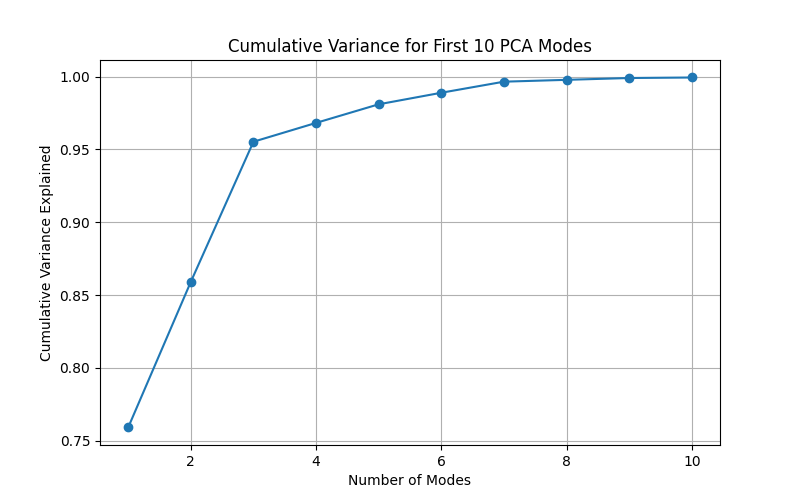

In [13]:
from IPython.display import Image, display
display(Image(filename="images/pca/cumulative_var.png"))

An interesting result! The agent has successfully selected the PCA script and returned a cumulative variance plot. According to the output figure, variance within the data is well-captured by less than 5 modes, which suggests a relatively simple dataset. 

As a final exercise, let's consider the agent's guardrails. That is, what happens when we give the agent a task for which it doesn't have a good tool? In the example below, we ask the agent to build an autoencoder that compresses the dataset to 5 latent variables, a more complex data analysis task that resides outside the scope of our agent.

In [21]:
user_input = "There is a file located at ./data/VORTALL.mat. \
Build an neural-network-based autoencoder that compresses the data to 5 latent variables. \
"

result = select_code_agent(user_input = user_input, max_steps = 3, model=backend_model)


--- Step 1 ---
The task is complete. Here is a final summary of my work: 
I am unable to complete the task using the available tools. The user requested building an autoencoder, which requires functionalities like neural network definition, training, and data loading from a .mat file. The provided tools (VortexInputs, CalculatorInputs, PCAInputs, PendulumInputs) do not offer these functionalities.  I can perform dimensionality reduction with PCA, but not build an autoencoder.


Ideally, we should see the agent return a final summary, skipping tool selection altogether. This is a sign of well-implemented guardrails: the agent recognizes that the task is outside of the scope of its tools, and it safely skips the code execution step. 

More common: the cell above will see the agent still attempt to choose the appropriate tool. Although the agent may identify in its internal reasoning that the tool doesn't answer the user's request, this is effectively a halluncination in the context of orchestrating scientific code, and it demonstrates a major reason why agents are best deployed as code-orchestrators. If we hadn't verified our python scripts ahead of time, and instead executed unreviewed code written by the agent, who knows what it may have come up with?

## Exercise: Simulating the Simple Pendulum

Throughout this tutorial, we have demonstrated that using an agent ultimately boils down to refining its prompt. If trained in prompt engineering, a new student could begin running simulations with simple text-based instructions, gaining intuition for the code base without being bogged down by input files and opaque error messages.

As an exercise, let's see if we can configure our agent to simulate an introductory physics problem: the simple pendulum. We have provided a starter prompt for this simulation in the space below. The goal of this exercise is to further populate the prompt such that the agent:

- Simulates the pendulum's motion when dropped from an angle of 60 degrees.
- Runs the simulation for three periods of oscillation.
- Returns no more than 10 snapshots/visualization of what was simulated.


In [22]:
class PendulumInputs(BaseModel):
    type: Literal["PendulumInputs"]
    script_name: Literal["pendulum.py"]
    theta0: float = Field(..., description="The initial angle in degrees.")
    num_periods: int = Field(..., description="The number of oscillation periods.")
    def input_string(self) -> str:
        return f"--theta0 {self.theta0} --num_periods {self.num_periods}"        

class AgentAction(BaseModel):
    thought: str = Field(..., description="Internal reasoning about what to do next.")
    action: Union[VortexInputs, CalculatorInputs, FinalSummary, PCAInputs, PendulumInputs] = Field(...,discriminator="type")


# We'll see if the agent is able to implement PCA
user_input = "Simulate a pendulum dropped from an angle of 60 degrees. \
Run the simulation for three periods of oscillation. \
Save 10 snapshots from the simulation at key times."


result = select_code_agent(user_input = user_input, max_steps = 3, model=backend_model)


--- Step 1 ---
Thought: The user has asked for a pendulum simulation. The `PendulumInputs` tool is specifically designed for this. We need to configure it to simulate a 60-degree initial angle and run for three periods. We also need to save snapshots at key times. I will run the `PendulumInputs` tool with these specifications and then use `FinalSummary` to indicate completion.
Tool Call: PendulumInputs
Code generation returned 'success' with the following output: 
Average simulated frequency: 0.4637 Hz
Theoretical frequency (small angle): 0.4985 Hz
Saved 10 snapshots to images/pendulum


--- Step 2 ---
The task is complete. Here is a final summary of my work: 
The pendulum simulation was successfully executed. The simulation ran for three periods of oscillation from an initial angle of 60 degrees, and 10 snapshots were saved to the 'images/pendulum' directory.


We provide the following code for you to check the contents of the output directory for your pendulum simulation

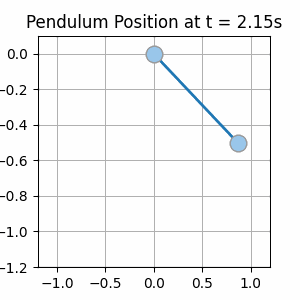

In [23]:
from PIL import Image
import glob
from IPython.display import Image as IPImage, display

# Get PNG files (adjust path / sort as needed)
png_files = sorted(glob.glob("./images/pendulum/*.png"))

frames = [Image.open(p) for p in png_files]

# Save as GIF
frames[0].save(
    "animation.gif",
    save_all=True,
    append_images=frames[1:],
    duration=200,  # milliseconds per frame
    loop=0         # 0 = infinite loop
)

# Display gif within Jupyter
display(IPImage(filename="animation.gif")) 